In [1]:
import tensorflow as tf
import os
import cv2
import numpy as np

IMG_ROW_SIZE = 384
IMG_COL_SIZE = 512
BATCH = 8


In [6]:


img_dir = "./Dataset/images"
mask_dir = "./Dataset/labels"

images = sorted(os.listdir(img_dir))
labels = sorted(os.listdir(mask_dir))


X = []
Y = []

for img_name in images:
    
    img = cv2.imread(os.path.join(img_dir, img_name))
    img = img / 255.0
    X.append(img)

for label_name in labels:
    
    mask = cv2.imread(os.path.join(mask_dir, label_name),0)
    mask = np.expand_dims(mask,-1)
    Y.append(mask)

X = np.array(X)
Y = np.array(Y)

print(X[0])


[[[0.12941176 0.18431373 0.17647059]
  [0.05490196 0.10980392 0.10196078]
  [0.07843137 0.13333333 0.1254902 ]
  ...
  [0.05098039 0.07843137 0.06666667]
  [0.04313725 0.07058824 0.05882353]
  [0.07843137 0.10588235 0.09411765]]

 [[0.10980392 0.16470588 0.15686275]
  [0.05098039 0.10588235 0.09803922]
  [0.06666667 0.12156863 0.11372549]
  ...
  [0.0627451  0.09019608 0.07843137]
  [0.05098039 0.07843137 0.06666667]
  [0.07843137 0.10588235 0.09411765]]

 [[0.07058824 0.1372549  0.1254902 ]
  [0.04705882 0.11372549 0.10196078]
  [0.07843137 0.14509804 0.13333333]
  ...
  [0.07058824 0.09803922 0.08627451]
  [0.0627451  0.09019608 0.07843137]
  [0.0745098  0.10196078 0.09019608]]

 ...

 [[0.09803922 0.20392157 0.19215686]
  [0.09803922 0.20392157 0.19215686]
  [0.11372549 0.2        0.19215686]
  ...
  [0.12156863 0.15294118 0.14901961]
  [0.14509804 0.17647059 0.17254902]
  [0.12941176 0.16078431 0.15686275]]

 [[0.09411765 0.19607843 0.19607843]
  [0.09019608 0.19215686 0.19215686]


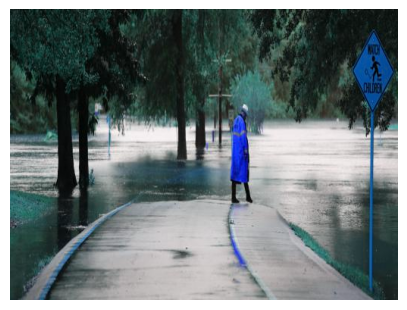

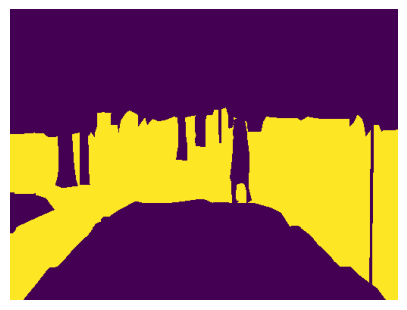

In [3]:

import matplotlib.pyplot as plt
plt.figure(figsize = (5,6))
plt.imshow(X[0])
plt.axis("off")
plt.show()

plt.figure(figsize = (5,6))
plt.imshow(Y[0])
plt.axis("off")
plt.show()


In [4]:

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)
X_train[0].shape


(384, 512, 3)

In [5]:

import tensorflow as tf

# =====================================================
# Local Attention Layer
# =====================================================

class LocalAttention(tf.keras.layers.Layer):
    def __init__(self, filters):
        super(LocalAttention, self).__init__()

        self.local_context = tf.keras.layers.DepthwiseConv2D(
            kernel_size=5,
            padding='same',
            activation='relu'
        )

        self.attn = tf.keras.layers.Conv2D(
            filters,
            1,
            activation='sigmoid'
        )

    def call(self, x):
        local_feat = self.local_context(x)
        weights = self.attn(local_feat)

        return x * weights + x



In [ ]:

# =====================================================
# Model
# =====================================================

inputs = tf.keras.Input(shape=(IMG_ROW_SIZE, IMG_COL_SIZE, 3))

# Encoder
x1 = tf.keras.layers.Conv2D(
    32, 3, activation='relu', padding='same'
)(inputs)

x1 = LocalAttention(32)(x1)

p1 = tf.keras.layers.MaxPool2D()(x1)


x2 = tf.keras.layers.Conv2D(
    64, 3, activation='relu', padding='same'
)(p1)

x2 = LocalAttention(64)(x2)

p2 = tf.keras.layers.MaxPool2D()(x2)


# Bottleneck
x3 = tf.keras.layers.Conv2D(
    128, 3, activation='relu', padding='same'
)(p2)

x3 = LocalAttention(128)(x3)


# Decoder
u1 = tf.keras.layers.UpSampling2D()(x3)

u1 = tf.keras.layers.Conv2D(
    64, 3, activation='relu', padding='same'
)(u1)

u1 = LocalAttention(64)(u1)


u2 = tf.keras.layers.UpSampling2D()(u1)

u2 = tf.keras.layers.Conv2D(
    32, 3, activation='relu', padding='same'
)(u2)

u2 = LocalAttention(32)(u2)


outputs = tf.keras.layers.Conv2D(
    1, 1, activation='sigmoid'
)(u2)


model = tf.keras.Model(inputs, outputs)

# =====================================================
# Compile
# =====================================================

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =====================================================
# Train
# =====================================================

model.fit(
    X_train,
    Y_train,
    epochs=10,
    batch_size=BATCH,
    validation_data=(X_test, Y_test)
)

model.evaluate(X_test, Y_test)


In [ ]:

pred = model.predict(X_test)
pred_mask = (pred > 0.5).astype(np.uint8)


In [ ]:

model.save("model.keras")
